# **Neuromorphic Human Activity Recognition (NeHAR) task**

In this notebook we benchmarked SNN-based models performing the Neuromorphic Human Activity Recognition (NeHAR) task using IMU sensor data acquired form a commercial smartwatch.

Human Activity Recognition (HAR) is a time-dependent task that has applications in various aspects of human life, from healthcare to sports, safety, and smart environments. In this task, we present a comparative analysis of different SNN-based models designed for classifying raw signals (Accelerometer and Gyroscope) collected in the Wireless Sensor Data Mining (WISDM) dataset.

The WISDM dataset consists of data from 51 subjects performing 18 activities. This dataset collects signals from both the accelerometer and the gyroscope of a smartphone and a smartwatch. Each activity is recorded for 3 minutes with an acquisition rate of 20 Hz. The dataset's classes are balanced, with each activity represented in the dataset contributing approximately 5.3% to 5.8% of the total approximately 15.63 million samples.
From the whole smartwatch dataset, we selected a subset of general hand-oriented activities for our analysis. These activities include: (1) dribbling in basketball, (2) playing catch with a tennis ball, (3) typing, (4) writing, (5) clapping, (6) brushing teeth, and (7) folding clothes. We divided the signals into non-overlapping temporal windows with a length of 2 seconds. These temporal windows serve as the input layer for the benchmarked models.

---

Refferring to the paper: Fra, V., Forno, E., Pignari, R., Stewart, T. C., Macii, E., & Urgese, G. (2022).
***Human activity recognition: suitability of a neuromorphic approach for on-edge AIoT applications. Neuromorphic Computing and Engineering***, 2(1), 014006.
DOI ***10.1088/2634-4386/ac4c38***



## Environment set-up

### Install packages in the Google Colab runtime

In [ ]:
%%capture
!pip install gdown
!pip install hyperopt
!pip install matplotlib
!pip install neurobench
!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install scipy
!pip install seaborn
!pip install snntorch
!pip install torch
!pip install tqdm

### Basic import



In [5]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle as pkl
import random
#from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

from neurobench.datasets import WISDM

from neurobench.metrics.static import Footprint
from neurobench.metrics.workload import ClassificationAccuracy

from neurobench.models import SNNTorchModel
from neurobench.processors.postprocessors import Aggregate, ChooseMaxCount
from neurobench.benchmarks import Benchmark

from neurobench.metrics.workload import (
    ActivationSparsity,
    MembraneUpdates,
    SynapticOperations,
    ClassificationAccuracy
)
from neurobench.metrics.static import (
    ParameterCount,
    Footprint,
    ConnectionSparsity,
)

import torch.nn as nn
from torch.utils.data import DataLoader
import snntorch as snn
from snntorch import surrogate
from snntorch import functional as SF
from snntorch import utils
import copy


### Utility functions and general settings

In [6]:
use_seed = True

if use_seed:
    seed = 42
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
else:
    seed = None

In [7]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

## Import HAR dataset

In [8]:
train_set = WISDM(root="../../data/nehar", split="train", download=True)
val_set   = WISDM(root="../../data/nehar", split="val",   download=True)
test_set  = WISDM(root="../../data/nehar", split="test",  download=True)

In [9]:
activities = [
    (0, 'A', 'walking'),
    (1, 'B', 'jogging'),
    (2, 'C', 'stairs'),
    (3, 'D', 'sitting'),
    (4, 'E', 'standing'),
    (5, 'F', 'typing'),
    (6, 'G', 'brushing_teeth'),
    (7, 'H', 'eating_soup'),
    (8, 'I', 'eating_chips'),
    (9, 'J', 'eating_pasta'),
    (10, 'K', 'drinking'),
    (11, 'L', 'eating_sandwich'),
    (12, 'M', 'kicking_soccer'),
    (13, 'O', 'catch_tennis'),
    (14, 'P', 'dribbling_basketball'),
    (15, 'Q', 'writing'),
    (16, 'R', 'clapping'),
    (17, 'S', 'folding_clothes'),
]

labels_activity = ["P", "O", "F", "Q", "R", "G", "S"] # we only take activities from the general hand orinted group

In [10]:
# Extract a random sample from the training set
random_sample = next(iter(DataLoader(train_set, batch_size=1, shuffle=True)))
random_data = random_sample[0]
random_label = random_sample[1]

In [11]:
# Randomly select a channel from IMU data
rnd_ch = np.random.randint(0,6)
print("Selected sample: {}".format(labels_activity[random_label]))
print("Selected channel: {}\n".format(rnd_ch))

random_ch = random_data[0,:,rnd_ch]
print("IMU values in time for the selected sample and channel:")
random_ch

Selected sample: O
Selected channel: 3

IMU values in time for the selected sample and channel:


tensor([-3.1116, -2.4498, -0.2478,  0.9206,  1.1765,  1.9210,  2.4407,  2.3167,
         2.1686,  2.3584,  2.3340,  2.2902,  1.4735,  0.8985,  1.2191, -0.1100,
         1.0021,  3.0523,  2.4772,  2.4704,  2.1474,  1.8547,  0.8731,  0.1227,
        -0.2115, -2.0238, -3.7869, -1.4500, -0.5940, -1.3643,  0.1332,  0.7430,
         1.1853,  2.4782,  5.1604,  1.6220,  0.8438,  2.0028,  1.8074,  4.8717])

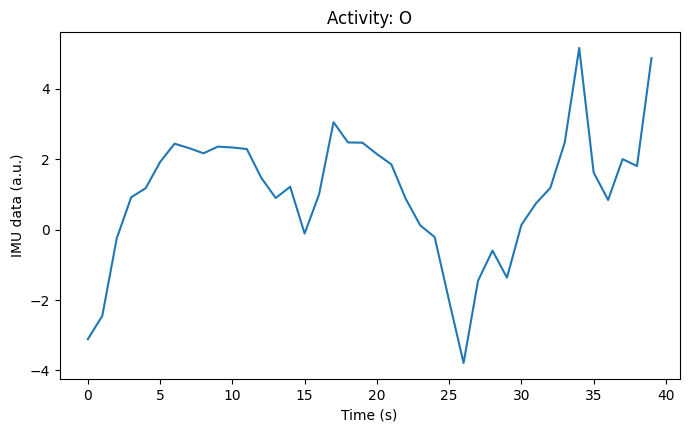

In [12]:
# Plot the random (original) example
plt.figure(figsize=(8,4.5))
plt.plot(random_ch.cpu().numpy())
plt.xlabel("Time (s)")
plt.ylabel("IMU data (a.u.)")
plt.title("Activity: {}".format(labels_activity[random_label]))
plt.show()

In [13]:
print("Training set \t ---data---\n \tnumber of samples: {}\n \tsample shape: {}".format(
    len(train_set),next(iter(DataLoader(train_set, batch_size=1, shuffle=False)))[0].shape))
print("Training set \t ---labels---\n \tnumber of labels: {}\n \tlabel shape: {}".format(
    len(train_set),next(iter(DataLoader(train_set, batch_size=1, shuffle=False)))[1].shape))
print("\n")
print("Validation set \t ---data---\n \tnumber of samples: {}\n \tshape: {}".format(
    len(val_set),next(iter(DataLoader(val_set, batch_size=1, shuffle=False)))[0].shape))
print("Validation set \t ---labels---\n \tnumber of labels: {}\n \tlabel shape: {}".format(
    len(val_set),next(iter(DataLoader(val_set, batch_size=1, shuffle=False)))[1].shape))
print("\n")
print("Test set \t ---data---\n \tnumber of samples: {}\n \tshape: {}".format(
    len(test_set),next(iter(DataLoader(test_set, batch_size=1, shuffle=False)))[0].shape))
print("Test set \t ---labels---\n \tnumber of labels: {}\n \tlabel shape: {}".format(
    len(test_set),next(iter(DataLoader(test_set, batch_size=1, shuffle=False)))[1].shape))

Training set 	 ---data---
 	number of samples: 18907
 	sample shape: torch.Size([1, 40, 6])
Training set 	 ---labels---
 	number of labels: 18907
 	label shape: torch.Size([1])


Validation set 	 ---data---
 	number of samples: 6302
 	shape: torch.Size([1, 40, 6])
Validation set 	 ---labels---
 	number of labels: 6302
 	label shape: torch.Size([1])


Test set 	 ---data---
 	number of samples: 6303
 	shape: torch.Size([1, 40, 6])
Test set 	 ---labels---
 	number of labels: 6303
 	label shape: torch.Size([1])


## Feedforward SNN

Training, Validation and Test of a FFSNN fully-connected

*Adapted from: V. Fra et al.; "Neuromorphic Human Activity Recognition through LIF-based neurons"; Brain-Inspired Computing Workshop 2023, Modena (Italy)*


Neurobench Metrics extraction

In [14]:
def training_loop(
    dataset,
    batch_size,
    net,
    optimizer,
    loss_fn,
    device):
    """
    Fra, Vittorio; Politecnico di Torino; EDA Group; Torino, Italy.
    """

    train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=False)

    batch_loss = []
    batch_acc = []

    for data, labels in tqdm(train_loader):

      data = data.to(device)#.swapaxes(1, 0)
      labels = labels.to(device)

      net.train()
      rec = net.single_forward(data)
      spk_rec = rec[0]

      # Training loss
      loss_val = loss_fn(spk_rec, labels)
      batch_loss.append(loss_val.detach().cpu().item())

      # Training accuracy
      act_total_out = torch.sum(spk_rec, 0)  # sum over time
      _, neuron_max_act_total_out = torch.max(act_total_out, 1)  # argmax over output units to compare to labels
      batch_acc.append(np.mean((neuron_max_act_total_out == labels).detach().cpu().numpy()))

      # Gradient calculation + weight update
      optimizer.zero_grad()
      loss_val.backward()
      optimizer.step()

    epoch_loss = np.mean(batch_loss)
    epoch_acc = np.mean(batch_acc)

    return [epoch_loss, epoch_acc]


def val_test_loop(
    dataset,
    batch_size,
    net,
    loss_fn,
    device,
    shuffle=True,
    label_probabilities=False,
    return_spikes=False):
    """
    Fra, Vittorio; Politecnico di Torino; EDA Group; Torino, Italy.
    """

    with torch.no_grad():
      net.eval()

      loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=False)

      batch_loss = []
      batch_acc = []

      for data, labels in tqdm(loader):
          data = data.to(device)#.swapaxes(1, 0)
          labels = labels.to(device)

          rec = net.single_forward(data)
          spk_out = rec[0]

          # Loss
          loss_val = loss_fn(spk_out, labels)
          batch_loss.append(loss_val.detach().cpu().item())

          # Accuracy
          act_total_out = torch.sum(spk_out, 0)  # sum over time
          _, neuron_max_act_total_out = torch.max(act_total_out, 1)  # argmax over output units to compare to labels
          batch_acc.append(np.mean((neuron_max_act_total_out == labels).detach().cpu().numpy()))

      if label_probabilities:
          log_softmax_fn = nn.LogSoftmax(dim=-1)
          log_p_y = log_softmax_fn(act_total_out)
          if return_spikes:
            return [np.mean(batch_loss), np.mean(batch_acc)], torch.exp(log_p_y), spk_out.detach().cpu().numpy()
          else:
            return [np.mean(batch_loss), np.mean(batch_acc)], torch.exp(log_p_y)
      else:
        if return_spikes:
          return [np.mean(batch_loss), np.mean(batch_acc)], spk_out.detach().cpu().numpy()
        else:
          return [np.mean(batch_loss), np.mean(batch_acc)]

In [15]:
settings= {"enc_pop": 32,
           "nb_hidden": 250,
           "beta_hid": 0.7,
           "beta_out": 0.65,
           "beta_enc": 0.2,
           "alpha_hid": 0.55,
           "alpha_out": 0.9,
           "thr_enc": 0.5,
           "thr_hid": 0.7,
           "thr_out": 0.9,
           "lr": 0.0001,
           "batch_size": 64
           }

In [16]:
network_results = []

In [17]:
### Network structure (input data --> encoding -> hidden -> output)
input_enc = 6
output_enc = int(settings["enc_pop"])
num_hidden = int(settings["nb_hidden"])
num_outputs = 7

num_steps = 40

class Net(nn.Module):
  def __init__(self):
    super().__init__()

    ##### Initialize layers #####
    ### Encoding layer
    self.enc = nn.Linear(input_enc, output_enc)
    self.s_enc = snn.Leaky(beta=settings['beta_enc'], threshold=settings['thr_enc'])
    ### Hidden layer
    self.fc1 = nn.Linear(output_enc, num_hidden)
    self.s1 = snn.Synaptic(beta=settings['beta_hid'], alpha=settings['alpha_hid'], threshold=settings['thr_hid'])
    ### Output layer
    self.fc2 = nn.Linear(num_hidden, num_outputs)
    self.s2 = snn.Synaptic(beta=settings['beta_out'], alpha=settings['alpha_out'], threshold=settings['thr_out'])
    self.mem_enc = self.s_enc.init_leaky()
    ### Hidden layer
    self.syn1, self.mem1 = self.s1.init_synaptic()
    ### Output layer
    self.syn2, self.mem2 = self.s2.init_synaptic()

  def single_forward(self, x):

    ### Encoding layer
    mem_enc = self.s_enc.init_leaky()
    ### Hidden layer
    syn1, mem1 = self.s1.init_synaptic()
    ### Output layer
    syn2, mem2 = self.s2.init_synaptic()

    # Record the final layer
    spk2_rec = []
    syn2_rec = []
    mem2_rec = []

    for step in range(num_steps):
      ### Encoding layer
      cur_enc = self.enc(x[:,step])
      spk_enc, mem_enc = self.s_enc(cur_enc, mem_enc)
      ### Hidden layer
      cur1 = self.fc1(spk_enc)
      spk1, syn1, mem1 = self.s1(cur1, syn1, mem1)
      ### Output layer
      cur2 = self.fc2(spk1)
      spk2, syn2, mem2 = self.s2(cur2, syn2, mem2)

      spk2_rec.append(spk2)
      syn2_rec.append(syn2)
      mem2_rec.append(mem2)

    return torch.stack(spk2_rec, dim=0), torch.stack(syn2_rec, dim=0), torch.stack(mem2_rec, dim=0)

  def forward(self, x):
       ### Encoding layer
      cur_enc = self.enc(x)
      spk_enc, self.mem_enc = self.s_enc(cur_enc, self.mem_enc)
      ### Hidden layer
      cur1 = self.fc1(spk_enc)
      spk1, self.syn1, self.mem1 = self.s1(cur1, self.syn1, self.mem1)
      ### Output layer
      cur2 = self.fc2(spk1)
      spk2, self.syn2, self.mem2 = self.s2(cur2, self.syn2, self.mem2)

      return spk2, self.mem2

  def reset(self):
    self.mem_enc = self.s_enc.init_leaky()
    ### Hidden layer
    self.syn1, self.mem1 = self.s1.init_synaptic()
    ### Output layer
    self.syn2, self.mem2 = self.s2.init_synaptic()


net = Net().to(device)

In [18]:
### Set the loss function
loss_fn = SF.ce_count_loss()

### Set the optimizer
optimizer = torch.optim.Adam(net.parameters(), lr=settings['lr'], betas=(0.9, 0.999))

### Set the batch size
batch_size = settings["batch_size"]

#### Training (with validation)

In [19]:
num_epochs = 100

In [20]:
training_results = []
validation_results = []

for epoch in range(num_epochs):

  train_loss, train_acc = training_loop(train_set, batch_size, net, optimizer, loss_fn, device)
  val_loss, val_acc = val_test_loop(val_set, batch_size, net, loss_fn, device)

  training_results.append([train_loss, train_acc])
  validation_results.append([val_loss, val_acc])

  print("Epoch {}/{}: \n\ttraining loss: {} \n\tvalidation loss: {} \n\ttraining accuracy: {}% \n\tvalidation accuracy: {}%".format(epoch+1, num_epochs, training_results[-1][0], validation_results[-1][0], np.round(training_results[-1][1]*100,4), np.round(validation_results[-1][1]*100,4)))

100%|██████████| 99/99 [00:01<00:00, 74.94it/s]


Epoch 1/100: 
	training loss: 3.3759105793527655 
	validation loss: 1.7644623542072797 
	training accuracy: 23.5032% 
	validation accuracy: 31.7624%


100%|██████████| 99/99 [00:01<00:00, 75.66it/s]


Epoch 2/100: 
	training loss: 1.7071530098045193 
	validation loss: 1.5852570064140088 
	training accuracy: 36.2329% 
	validation accuracy: 42.2001%


100%|██████████| 99/99 [00:01<00:00, 70.04it/s]


...

Epoch 98/100: 
	training loss: 0.37562792499021097 
	validation loss: 0.4842285561290654 
	training accuracy: 88.8349% 
	validation accuracy: 87.0697%


100%|██████████| 99/99 [00:01<00:00, 73.62it/s]


Epoch 99/100: 
	training loss: 0.36643664601787523 
	validation loss: 0.4813725696970718 
	training accuracy: 89.0091% 
	validation accuracy: 86.0911%


100%|██████████| 99/99 [00:01<00:00, 74.07it/s]

Epoch 100/100: 
	training loss: 0.37274828339247285 
	validation loss: 0.427990112039778 
	training accuracy: 88.8019% 
	validation accuracy: 88.1292%


#### Test

In [21]:
test_results, lbl_probs, spk_out = val_test_loop(test_set, batch_size, net, loss_fn, device, label_probabilities=True, return_spikes=True)

print("\nTest accuracy: {}%".format(np.round(test_results[1]*100,4)))

100%|██████████| 99/99 [00:01<00:00, 73.25it/s]


Test accuracy: 87.8294%


#### Save model

In [22]:
os.makedirs('./model_data', exist_ok=True)
torch.save(net.state_dict(), './model_data/HAR_FFSNN.pth')

#### Neurobench Metrics

In [23]:
net = Net().to(device)
net.load_state_dict(torch.load('./model_data/HAR_FFSNN.pth'))

model = SNNTorchModel(net)
test_set_loader = DataLoader(test_set, batch_size=settings["batch_size"], shuffle=True, drop_last=False)
postprocessors = [ChooseMaxCount()]

static_metrics = [ParameterCount, Footprint, ConnectionSparsity]
workload_metrics = [ActivationSparsity, MembraneUpdates, SynapticOperations, ClassificationAccuracy]

benchmark = Benchmark(model, test_set_loader, [], postprocessors, [static_metrics, workload_metrics])
results = benchmark.run()
print(results)

results = [results[key] for key in results.keys()]
results.insert(0, 'FFSNN')

network_results.append(copy.copy(results))


Running benchmark


100%|██████████| 99/99 [00:04<00:00, 21.17it/s]

{'ParameterCount': 10231, 'Footprint': 40992, 'ConnectionSparsity': 0.0, 'ActivationSparsity': 0.7368406020750266, 'MembraneUpdates': 11559.993019197207, 'SynapticOperations': {'Effective_MACs': 7680.0, 'Effective_ACs': 157819.0834523243, 'Dense': 397680.0}, 'ClassificationAccuracy': 0.8779946057527545}


#### Single-sample inference

In [24]:
single_sample = next(iter(DataLoader(test_set, batch_size=1, shuffle=True)))
print("Randomly selected sample: {}".format(labels_activity[single_sample[1].cpu()[0]]))

Randomly selected sample: G


100%|██████████| 1/1 [00:00<00:00, 38.32it/s]


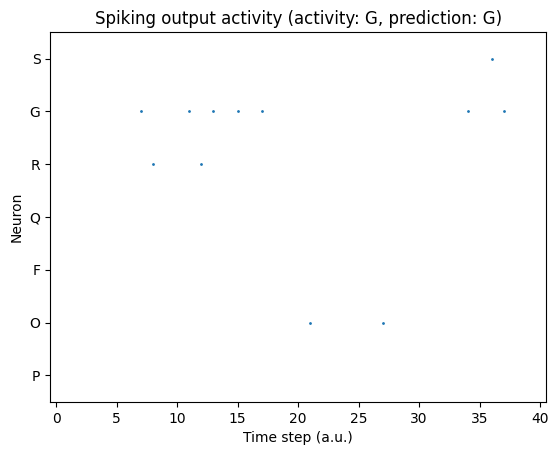


Labels probabilities:
	P 
		0.09%
	O 
		0.66%
	F 
		0.09%
	Q 
		0.09%
	R 
		0.66%
	G 
		98.17%
	S 
		0.24%


In [25]:
### Inference
_, lbl_probs, spk_out = val_test_loop(TensorDataset(single_sample[0],single_sample[1]), 1, net, loss_fn, device, label_probabilities=True, return_spikes=True)

### Plot output spiking activity
spk_out = np.moveaxis(spk_out,1,2)
spk_out = np.squeeze(spk_out, axis=-1)
spk_out.shape
aer = []
for num,el in enumerate(spk_out):
  addr = np.where(el)[0].tolist()
  if len(addr) > 0:
    for ii in addr:
      aer.append([num,ii])
aer = np.array(aer)
plt.scatter(aer[:,0], aer[:,1], s=1)
plt.xlabel("Time step (a.u.)")
plt.ylabel("Neuron")
plt.title("Spiking output activity (activity: {}, prediction: {})".format(labels_activity[single_sample[1].cpu()[0]],labels_activity[np.argmax(lbl_probs.cpu())]))
plt.ylim(-0.5,6.5)
plt.xlim((-0.5,num_steps+0.5))
plt.yticks(range(7),labels_activity)
plt.show()

print("\nLabels probabilities:")
for num,el in enumerate(labels_activity):
  print("\t{} \n\t\t{}%".format(el,np.round(lbl_probs.cpu().numpy()[0][num]*100,2)))

## Recurrent SNN

Training, Validation and Test of a fully-connected RSNN

*Adapted from: V. Fra et al.; "Neuromorphic Human Activity Recognition through LIF-based neurons"; Brain-Inspired Computing Workshop 2023, Modena (Italy)*


Neurobench Metrics extraction

In [26]:
def training_loop(
    dataset,
    batch_size,
    net,
    optimizer,
    loss_fn,
    device):
    """
    Fra, Vittorio; Politecnico di Torino; EDA Group; Torino, Italy.
    """

    train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=False)

    batch_loss = []
    batch_acc = []

    for data, labels in tqdm(train_loader):

      data = data.to(device)#.swapaxes(1, 0)
      labels = labels.to(device)

      net.train()
      rec = net.single_forward(data)
      spk_rec = rec[0]

      # Training loss
      loss_val = loss_fn(spk_rec, labels)
      batch_loss.append(loss_val.detach().cpu().item())

      # Training accuracy
      act_total_out = torch.sum(spk_rec, 0)  # sum over time
      _, neuron_max_act_total_out = torch.max(act_total_out, 1)  # argmax over output units to compare to labels
      batch_acc.append(np.mean((neuron_max_act_total_out == labels).detach().cpu().numpy()))

      # Gradient calculation + weight update
      optimizer.zero_grad()
      loss_val.backward()
      optimizer.step()

    epoch_loss = np.mean(batch_loss)
    epoch_acc = np.mean(batch_acc)

    return [epoch_loss, epoch_acc]


def val_test_loop(
    dataset,
    batch_size,
    net,
    loss_fn,
    device,
    shuffle=True,
    label_probabilities=False,
    return_spikes=False):
    """
    Fra, Vittorio; Politecnico di Torino; EDA Group; Torino, Italy.
    """

    with torch.no_grad():
      net.eval()

      loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=False)

      batch_loss = []
      batch_acc = []

      for data, labels in tqdm(loader):
          data = data.to(device)#.swapaxes(1, 0)
          labels = labels.to(device)

          rec = net.single_forward(data)
          spk_out = rec[0]

          # Loss
          loss_val = loss_fn(spk_out, labels)
          batch_loss.append(loss_val.detach().cpu().item())

          # Accuracy
          act_total_out = torch.sum(spk_out, 0)  # sum over time
          _, neuron_max_act_total_out = torch.max(act_total_out, 1)  # argmax over output units to compare to labels
          batch_acc.append(np.mean((neuron_max_act_total_out == labels).detach().cpu().numpy()))

      if label_probabilities:
          log_softmax_fn = nn.LogSoftmax(dim=-1)
          log_p_y = log_softmax_fn(act_total_out)
          if return_spikes:
            return [np.mean(batch_loss), np.mean(batch_acc)], torch.exp(log_p_y), spk_out.detach().cpu().numpy()
          else:
            return [np.mean(batch_loss), np.mean(batch_acc)], torch.exp(log_p_y)
      else:
        if return_spikes:
          return [np.mean(batch_loss), np.mean(batch_acc)], spk_out.detach().cpu().numpy()
        else:
          return [np.mean(batch_loss), np.mean(batch_acc)]

In [27]:
settings = {"neurons_per_pop": 5.0,
            "output_pop": 32.0,
            "nb_hidden": 250.0,
            "alpha_hid": 0.55,
            "alpha_out": 0.9,
            "beta_hid": 0.7,
            "beta_out": 0.65,
            "beta_enc": 0.2,
            "lr": 0.0001,
            "slope": 15.0,
            "batch_size": 64.0
            }

In [42]:
### Network structure (input data --> encoding -> hidden -> output)
input_channels = 6
pop_size = int(settings["neurons_per_pop"]) # --> the number of neurons for the encoding layer with populations will be: pop_size*input_channels
output_pop = int(settings["output_pop"])
output_enc = output_pop*input_channels
num_hidden = int(settings["nb_hidden"])
num_outputs = 7

num_steps = 40

### Surrogate gradient setting
spike_grad = surrogate.fast_sigmoid(slope=int(settings["slope"]))


class Net(nn.Module):

    def __init__(self):

        super().__init__()

        ##### Define layers #####
        ### Encoding layer with populations
        self.pop_size = pop_size
        self.enc_pops = []
        self.lif_enc_pops = []
        for ii in range(input_channels):
            self.enc_pops.append(nn.Linear(pop_size, output_pop).to(device))
            self.lif_enc_pops.append(snn.Leaky(beta=settings["beta_enc"], learn_beta=True, learn_threshold=True).to(device))
        self.enc_pops = nn.ModuleList(self.enc_pops)
        self.lif_enc_pops = nn.ModuleList(self.lif_enc_pops)
        ### Recurrent layer
        self.fc1 = nn.Linear(output_enc, num_hidden)
        self.lif1 = snn.RSynaptic(alpha=settings["alpha_hid"], beta=settings["beta_hid"], learn_alpha=True, learn_beta=True, learn_threshold=True, linear_features=num_hidden, spike_grad=spike_grad)
        ### Output layer
        self.fc2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.Synaptic(alpha=settings["alpha_out"], beta=settings["beta_out"], learn_alpha=True, learn_beta=True, learn_threshold=True)

        # NOTE that this is actually redundant outside of NeuroBench benchmarking
        ##### Initialize hidden states at t=0 #####
        ### Encoding layer with populations
        self.mem_pops_enc = [
            torch.zeros(int(settings["batch_size"]), output_pop, device=device)
            for _ in range(input_channels)
        ]
        self.spk_pops_enc = [
            torch.zeros(int(settings["batch_size"]), output_pop, device=device)
            for _ in range(input_channels)
        ]
        self.cur_pops_enc = [
            torch.zeros(int(settings["batch_size"]), output_pop, device=device)
            for _ in range(input_channels)
        ]
        
        ### Recurrent layer
        self.spk1, self.syn1, self.mem1 = self.lif1.init_rsynaptic()
        ### Output layer
        self.syn2, self.mem2 = self.lif2.init_synaptic()


    def single_forward(self, x):

        x = x.swapaxes(1, 0)
        utils.reset(self)

        ##### Initialize hidden states at t=0 #####
        ### Encoding layer with populations
        mem_pops_enc = [
            torch.zeros(x.shape[1], output_pop, dtype=torch.float, device=device)
            for _ in range(input_channels)
        ]
        ### Recurrent layer
        spk1, syn1, mem1 = self.lif1.init_rsynaptic()
        ### Output layer
        syn2, mem2 = self.lif2.init_synaptic()

        # Record the final layer
        spk2_rec = []
        syn2_rec = []
        mem2_rec = []

        for step in range(num_steps):
            ### Encoding layer with populations
            cur_list, spk_list = [], []
            for num, el in enumerate(self.enc_pops):
                cur_list.append(el(torch.tile(x[step, :, num], (self.pop_size, 1)).swapaxes(1, 0)))
            for num, el in enumerate(self.lif_enc_pops):
                spk, mem = el(cur_list[num], mem_pops_enc[num])
                spk_list.append(spk)
                mem_pops_enc[num] = mem  # no detach here — grads flow through time within single_forward

            spk_enc = torch.stack(spk_list, dim=1).reshape((x.shape[1], input_channels * output_pop))

            ### Recurrent layer
            cur1 = self.fc1(spk_enc)
            spk1, syn1, mem1 = self.lif1(cur1, spk1, syn1, mem1)
            ### Output layer
            cur2 = self.fc2(spk1)
            spk2, syn2, mem2 = self.lif2(cur2, syn2, mem2)

            spk2_rec.append(spk2)
            syn2_rec.append(syn2)
            mem2_rec.append(mem2)

        return torch.stack(spk2_rec, dim=0), torch.stack(syn2_rec, dim=0), torch.stack(mem2_rec, dim=0)


    def forward(self, x):
        ### Encoding layer with populations
        cur_list, spk_list = [], []
        for num, el in enumerate(self.enc_pops):
            cur_list.append(el(torch.tile(x[:, num], (self.pop_size, 1)).swapaxes(1, 0)))
        for num, el in enumerate(self.lif_enc_pops):
            spk, mem = el(cur_list[num], self.mem_pops_enc[num])
            spk_list.append(spk)
            # Update mem state out-of-place
            self.mem_pops_enc[num] = mem.detach()  # detach state for next step

        spk_enc = torch.stack(spk_list, dim=1).reshape((x.shape[0], input_channels * output_pop))

        ### Recurrent layer
        cur1 = self.fc1(spk_enc)
        self.spk1, self.syn1, self.mem1 = self.lif1(cur1, self.spk1, self.syn1, self.mem1)

        ### Output layer
        cur2 = self.fc2(self.spk1)
        spk2, self.syn2, self.mem2 = self.lif2(cur2, self.syn2, self.mem2)

        return spk2, self.mem2

    # def reset(self, x):
    #     ### Encoding layer with populations
    #     self.mem_pops_enc = torch.empty((input_channels,x.shape[1],output_pop), dtype=torch.float, device=device)
    #     self.spk_pops_enc = torch.empty((input_channels,x.shape[1],output_pop), dtype=torch.float, device=device)
    #     self.cur_pops_enc = torch.empty((input_channels,x.shape[1],output_pop), dtype=torch.float, device=device)
    #     ### Hidden layer
    #     self.spk1, self.syn1, self.mem1 = self.lif1.init_rsynaptic()
    #     ### Output layer
    #     self.syn2, self.mem2 = self.lif2.init_synaptic()


net = Net().to(device)

In [43]:
### Set the loss function
loss_fn = SF.ce_count_loss()

### Set the optimizer
optimizer = torch.optim.Adam(net.parameters(), lr=settings['lr'], betas=(0.9, 0.999))

### Set the batch size
batch_size = int(settings["batch_size"])

#### Training (with validation)

In [44]:
num_epochs = 100

In [45]:
training_results = []
validation_results = []

for epoch in range(num_epochs):

  train_loss, train_acc = training_loop(train_set, batch_size, net, optimizer, loss_fn, device)
  val_loss, val_acc = val_test_loop(val_set, batch_size, net, loss_fn, device)

  training_results.append([train_loss, train_acc])
  validation_results.append([val_loss, val_acc])

  print("Epoch {}/{}: \n\ttraining loss: {} \n\tvalidation loss: {} \n\ttraining accuracy: {}% \n\tvalidation accuracy: {}%".format(epoch+1, num_epochs, training_results[-1][0], validation_results[-1][0], np.round(training_results[-1][1]*100,4), np.round(validation_results[-1][1]*100,4)))

100%|██████████| 99/99 [00:03<00:00, 29.02it/s]


Epoch 1/100: 
	training loss: 1.875180871100039 
	validation loss: 0.8205959510923636 
	training accuracy: 61.9379% 
	validation accuracy: 75.1883%


100%|██████████| 99/99 [00:03<00:00, 29.36it/s]


Epoch 2/100: 
	training loss: 0.7228005035100756 
	validation loss: 0.5768391587818512 
	training accuracy: 78.0282% 
	validation accuracy: 82.9356%


100%|██████████| 99/99 [00:03<00:00, 29.11it/s]


...

Epoch 98/100: 
	training loss: 0.044958821656748756 
	validation loss: 0.2930543591277768 
	training accuracy: 98.2402% 
	validation accuracy: 94.1877%


100%|██████████| 99/99 [00:03<00:00, 29.59it/s]


Epoch 99/100: 
	training loss: 0.04952249901150542 
	validation loss: 0.3123697786676613 
	training accuracy: 98.1663% 
	validation accuracy: 94.4855%


100%|██████████| 99/99 [00:03<00:00, 28.75it/s]

Epoch 100/100: 
	training loss: 0.052513046477247985 
	validation loss: 0.2941614454706209 
	training accuracy: 98.0416% 
	validation accuracy: 94.456%


#### Test

In [46]:
test_results, lbl_probs, spk_out = val_test_loop(test_set, batch_size, net, loss_fn, device, label_probabilities=True, return_spikes=True)

print("\nTest accuracy: {}%".format(np.round(test_results[1]*100,4)))

100%|██████████| 99/99 [00:03<00:00, 27.58it/s]


Test accuracy: 94.1919%


#### Save model

In [47]:
os.makedirs('./model_data', exist_ok=True)
torch.save(net.state_dict(), './model_data/HAR_RSNN.pth')

#### Neurobench Metrics

In [48]:
net = Net().to(device)
net.load_state_dict(torch.load('./model_data/HAR_RSNN.pth'))

model = SNNTorchModel(net)
test_set_loader = DataLoader(test_set, batch_size=int(settings["batch_size"]), shuffle=True, drop_last=False)
postprocessors = [ChooseMaxCount()]

static_metrics = [ParameterCount, Footprint, ConnectionSparsity]
workload_metrics = [ActivationSparsity, MembraneUpdates, SynapticOperations, ClassificationAccuracy]

benchmark = Benchmark(model, test_set_loader, [], postprocessors, [static_metrics, workload_metrics])
results = benchmark.run()

results = [results[key] for key in results.keys()]
results.insert(0, 'RSNN')

network_results.append(copy.copy(results))

Running benchmark


100%|██████████| 99/99 [00:13<00:00,  7.10it/s]


#### Single-sample inference

In [49]:
single_sample = next(iter(DataLoader(test_set, batch_size=1, shuffle=True)))
print("Randomly selected sample: {}".format(labels_activity[single_sample[1].cpu()[0]]))

Randomly selected sample: R


100%|██████████| 1/1 [00:00<00:00, 20.35it/s]


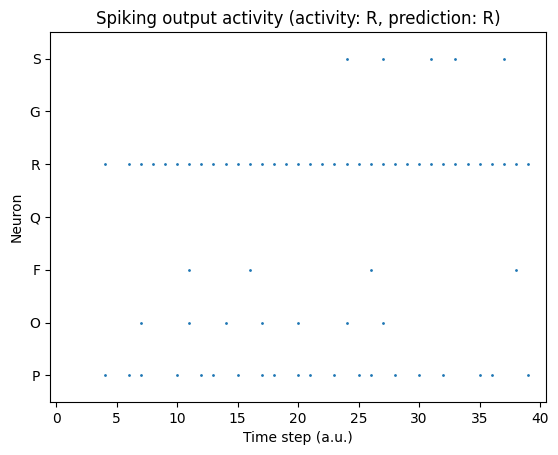


Labels probabilities:
	P 
		0.0%
	O 
		0.0%
	F 
		0.0%
	Q 
		0.0%
	R 
		100.0%
	G 
		0.0%
	S 
		0.0%


In [50]:
### Inference
_, lbl_probs, spk_out = val_test_loop(TensorDataset(single_sample[0],single_sample[1]), 1, net, loss_fn, device, label_probabilities=True, return_spikes=True)

### Plot output spiking activity
spk_out = np.moveaxis(spk_out,1,2)
spk_out = np.squeeze(spk_out, axis=-1)
spk_out.shape
aer = []
for num,el in enumerate(spk_out):
  addr = np.where(el)[0].tolist()
  if len(addr) > 0:
    for ii in addr:
      aer.append([num,ii])
aer = np.array(aer)
plt.scatter(aer[:,0], aer[:,1], s=1)
plt.xlabel("Time step (a.u.)")
plt.ylabel("Neuron")
plt.title("Spiking output activity (activity: {}, prediction: {})".format(labels_activity[single_sample[1].cpu()[0]],labels_activity[np.argmax(lbl_probs.cpu())]))
plt.ylim(-0.5,6.5)
plt.xlim((-0.5,num_steps+0.5))
plt.yticks(range(7),labels_activity)
plt.show()

print("\nLabels probabilities:")
for num,el in enumerate(labels_activity):
  print("\t{} \n\t\t{}%".format(el,np.round(lbl_probs.cpu().numpy()[0][num]*100,2)))

## Convolutional SNN

Training, Validation and Test of a CSNN

Neurobench Metrics extraction

In [51]:
settings = {
    'conv_1_out_fts': 200,
    'conv_1_kernel_size': 2,
    'maxpool_1_fts': 2,
    'conv_1_pad': 4,
    'leaky_1_beta': 0.4,
    'leaky_1_thr': 0.002,
    'conv_2_in_fts': 100,
    'conv_2_out_fts': 256,
    'conv_2_kernel_size': 1,
    'maxpool_2_fts': 2,
    'leaky_2_beta': 0.3,
    'leaky_2_thr': 0.001,
    'leaky_3_beta': 0.5,
    'leaky_3_thr': 0.001,
    'lr': 1.e-3,
    'batch_size': 256,
}

In [52]:
input_enc = 6
num_outputs = 7
num_steps = 40

class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(input_enc, settings['conv_1_out_fts'], kernel_size=settings['conv_1_kernel_size'], padding=settings['conv_1_pad'])
        self.max1 = nn.MaxPool2d(settings['maxpool_1_fts'])
        self.leaky1 = snn.Leaky(beta=settings['leaky_1_beta'], init_hidden=True, threshold=settings['leaky_1_thr'])
        self.conv2 = nn.Conv1d(settings['conv_2_in_fts'], settings['conv_2_out_fts'], kernel_size=settings['conv_2_kernel_size'])
        self.max2 = nn.MaxPool2d(settings['maxpool_2_fts'])
        self.leaky2 = snn.Leaky(beta=settings['leaky_2_beta'], init_hidden=True, threshold=settings['leaky_2_thr'])
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(settings['conv_2_out_fts'], num_outputs)
        self.leaky3 = snn.Leaky(beta=settings['leaky_3_beta'], output=True, init_hidden=True, threshold=settings['leaky_3_thr'])


    def forward(self, input):

        x = self.conv1(input.reshape(input.shape[0], input.shape[1], 1))
        x = self.max1(x)
        x = self.leaky1(x)
        x = self.conv2(x)
        x = self.max2(x)
        x = self.leaky2(x)
        x = self.flatten(x)
        x = self.linear(x)
        spk_out, mem_out = self.leaky3(x)
        return spk_out, mem_out

    def single_forward(self, input):
        mem_rec = []
        spk_rec = []

        self.leaky1.init_leaky()
        self.leaky2.init_leaky()
        self.leaky3.init_leaky()
        utils.reset(self)
        for step in range(num_steps):

            new_input = input[:, step, :]
            x = self.conv1(new_input.reshape(new_input.shape[0], new_input.shape[1], 1))
            x = self.max1(x)
            x = self.leaky1(x)
            x = self.conv2(x)
            x = self.max2(x)
            x = self.leaky2(x)
            x = self.flatten(x)
            x = self.linear(x)
            spk_out, mem_out = self.leaky3(x)

            spk_rec.append(spk_out)
            mem_rec.append(mem_out)

        return torch.stack(spk_rec), torch.stack(mem_rec)

    def reset(self):
      self.leaky1.init_leaky()
      self.leaky2.init_leaky()
      self.leaky3.init_leaky()

    def frequency(self):
      acquisition_rate = 20
      temporal_window = num_steps/acquisition_rate
      return 1/temporal_window


net = Net().to(device)

In [53]:
### Set the loss function
loss_fn = SF.ce_count_loss()

### Set the optimizer
optimizer = torch.optim.Adam(net.parameters(), lr=settings['lr'], betas=(0.9, 0.999))

### Set the batch size
batch_size = settings["batch_size"]

#### Training (with validation)

In [54]:
num_epochs = 100

training_results = []
validation_results = []

for epoch in range(num_epochs):

  train_loss, train_acc = training_loop(train_set, batch_size, net, optimizer, loss_fn, device)
  val_loss, val_acc = val_test_loop(val_set, batch_size, net, loss_fn, device)

  training_results.append([train_loss, train_acc])
  validation_results.append([val_loss, val_acc])

  print("Epoch {}/{}: \n\ttraining loss: {} \n\tvalidation loss: {} \n\ttraining accuracy: {}% \n\tvalidation accuracy: {}%".format(epoch+1, num_epochs, training_results[-1][0], validation_results[-1][0], np.round(training_results[-1][1]*100,4), np.round(validation_results[-1][1]*100,4)))

100%|██████████| 25/25 [00:11<00:00,  2.19it/s]


Epoch 1/100: 
	training loss: 3.930408704925228 
	validation loss: 2.7289875507354737 
	training accuracy: 19.6308% 
	validation accuracy: 40.4365%


100%|██████████| 25/25 [00:11<00:00,  2.14it/s]


Epoch 2/100: 
	training loss: 3.3495741293237016 
	validation loss: 2.7219374275207517 
	training accuracy: 45.3093% 
	validation accuracy: 47.6784%


100%|██████████| 25/25 [00:11<00:00,  2.19it/s]


...

Epoch 98/100: 
	training loss: 0.5541745520926811 
	validation loss: 0.7743546533584594 
	training accuracy: 90.2939% 
	validation accuracy: 88.3918%


100%|██████████| 25/25 [00:11<00:00,  2.15it/s]


Epoch 99/100: 
	training loss: 0.49875771959085724 
	validation loss: 0.5509864515066147 
	training accuracy: 90.755% 
	validation accuracy: 90.4753%


100%|██████████| 25/25 [00:12<00:00,  2.06it/s]

Epoch 100/100: 
	training loss: 0.4375953976366971 
	validation loss: 0.5840545129776001 
	training accuracy: 91.5582% 
	validation accuracy: 90.8137%


#### Test

In [55]:
test_results, lbl_probs, spk_out = val_test_loop(test_set, batch_size, net, loss_fn, device, label_probabilities=True, return_spikes=True)

print("\nTest accuracy: {}%".format(np.round(test_results[1]*100,4)))

100%|██████████| 25/25 [00:11<00:00,  2.20it/s]


Test accuracy: 91.4359%


#### Save model

In [56]:
os.makedirs('./model_data', exist_ok=True)
torch.save(net.state_dict(), './model_data/HAR_SCNN.pth')

#### Neurobench Metrics

In [57]:
net = Net().to(device)
net.load_state_dict(torch.load('./model_data/HAR_SCNN.pth'))

model = SNNTorchModel(net)
test_set_loader = DataLoader(test_set, batch_size=settings["batch_size"], shuffle=True, drop_last=False)
postprocessors = [ChooseMaxCount()]

static_metrics = [ParameterCount, Footprint, ConnectionSparsity]
workload_metrics = [ActivationSparsity, MembraneUpdates, SynapticOperations, ClassificationAccuracy]

benchmark = Benchmark(model, test_set_loader, [], postprocessors, [static_metrics, workload_metrics])
results = benchmark.run()

results = [results[key] for key in results.keys()]
results.insert(0, 'SCNN')

network_results.append(copy.copy(results))

Running benchmark


100%|██████████| 25/25 [00:28<00:00,  1.16s/it]


## Networks Results

In [58]:
pd.DataFrame(network_results, columns=['Network', 'ParameterCount', 'Footprint', 'ConnectionSparsity', 'ActivationSparsity', 'MembraneUpdates', 'SynapticOperations', 'ClassificationAccuracy'])

,Network,ParameterCount,Footprint,ConnectionSparsity,ActivationSparsity,MembraneUpdates,SynapticOperations,ClassificationAccuracy
0,FFSNN,10231,40992,0.0,0.736841,11559.993019,"{'Effective_MACs': 7680.0, 'Effective_ACs': 15...",0.877995
1,RSNN,113927,455804,0.0,0.882571,17959.993812,"{'Effective_MACs': 38400.0, 'Effective_ACs': 5...",0.768523
2,SCNN,30255,121080,0.0,0.468978,21906.563700,"{'Effective_MACs': 96000.0, 'Effective_ACs': 2...",0.914009
